Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Interpretation
Imported the required libraries for data manipulation and visualization.

In [4]:
df = pd.read_csv("/content/Zoo.csv")
df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


Interpretation

Loaded the Zoo dataset successfully.
Displayed the first five records.

Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


Statistical Summary

In [6]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


Interpretation

Displays mean, standard deviation, minimum, maximum, and quartiles.
Helps understand the distribution of numerical features.

Check Missing Value

In [7]:
df.isnull().sum()

,0
animal name,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0


Interpretation

The Zoo dataset contains no missing values.

```
# This is formatted as code
```



Check Duplicate Values

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

Check Outliers

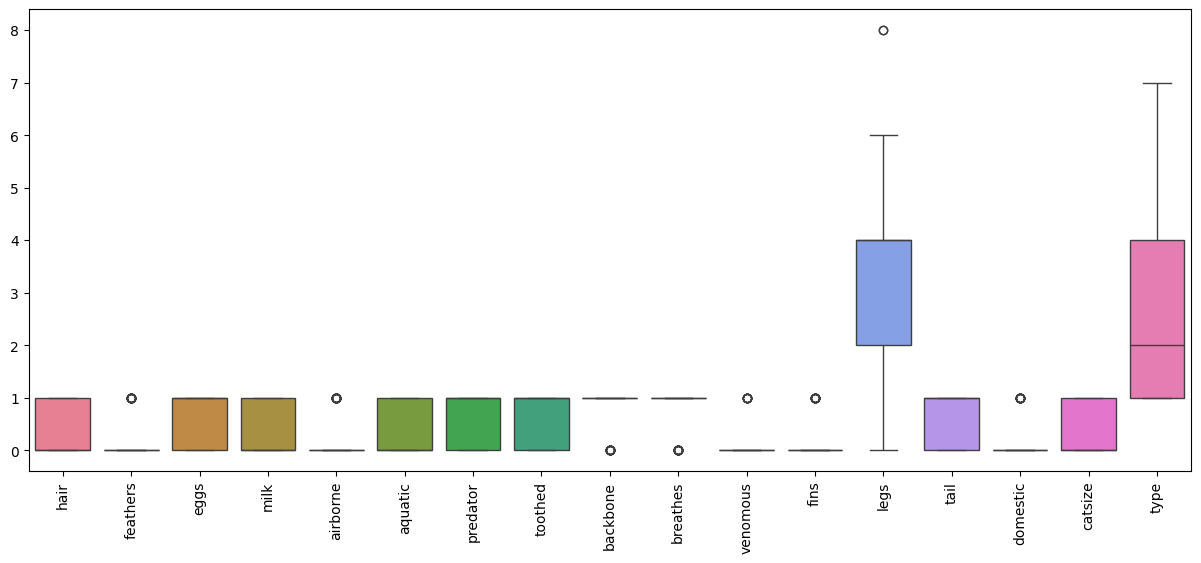

In [10]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df.drop(columns=['animal name']))
plt.xticks(rotation=90)
plt.show()

Interpretation

Boxplots help detect outliers.

Since most variables are binary (0/1), outliers are minimal.

No outlier treatment is required.

Data Visualization

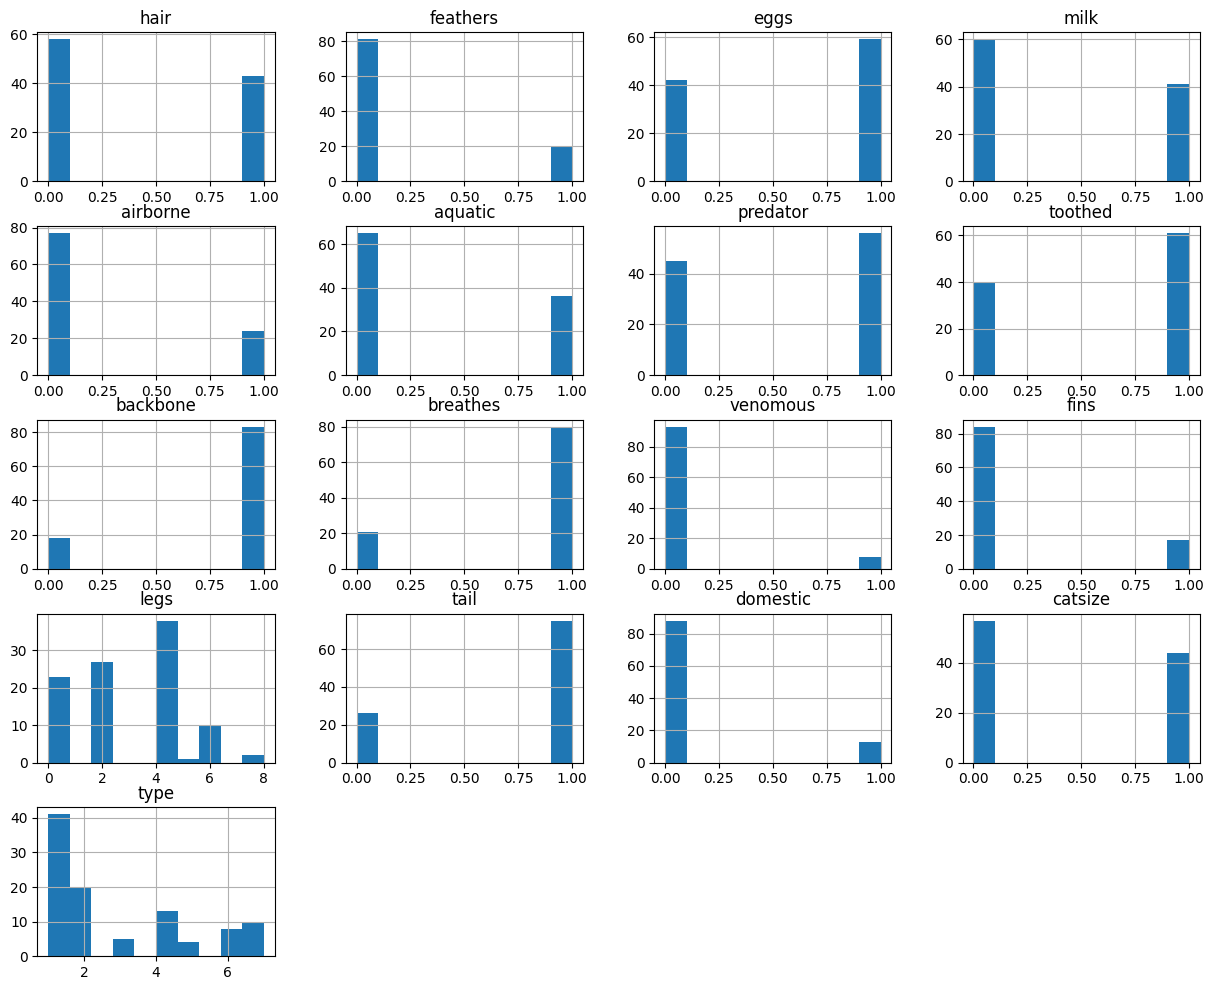

In [11]:
df.hist(figsize=(15,12))
plt.show()

Interpretation

Histograms show the distribution of each feature

Correlation Heatmap

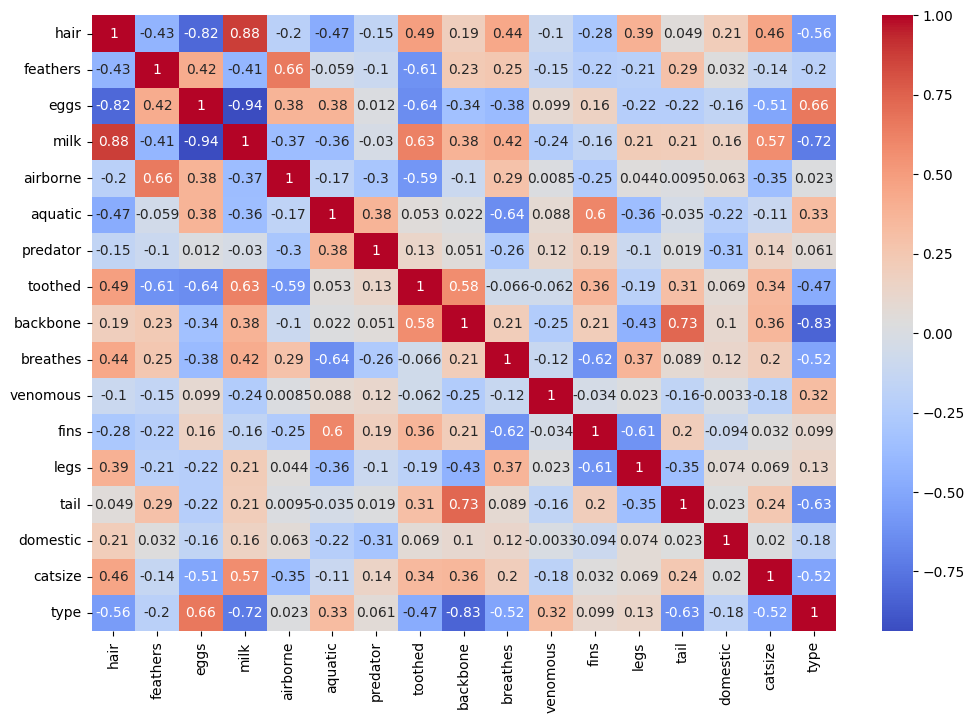

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.drop(columns=['animal name']).corr(), annot=True, cmap='coolwarm')
plt.show()

Interpretation

The heatmap shows relationships among features.

Some features have strong positive correlations.

Count Plot of Target Variable

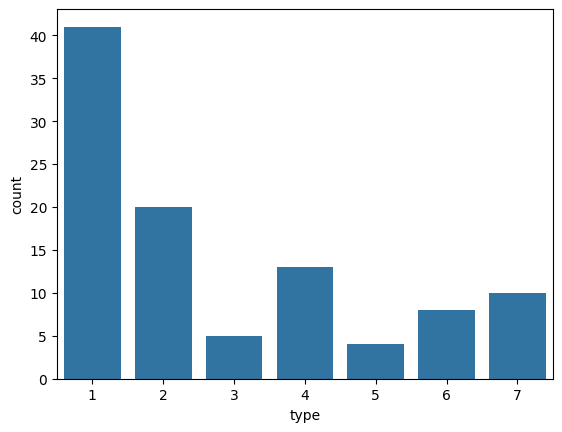

In [13]:
sns.countplot(x='type', data=df)
plt.show()

Interpretation

Shows the number of animals in each class.

Some classes contain fewer samples than others.

Data Preprocessing
Remove the animal name because it is only an identifier.

In [14]:
df = df.drop('animal name', axis=1)

Interpretation

The animal name is not useful for prediction.

Split Features and Target

In [15]:
X = df.drop('type', axis=1)
y = df['type']

Interpretation

X contains predictor variables.

y contains the target class.

Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Interpretation

Standardization ensures all features are on a similar scale.
KNN performs better with scaled data.

Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

Interpretation
80% of the data is used for training.
20% is used for testing.

Choose K Value

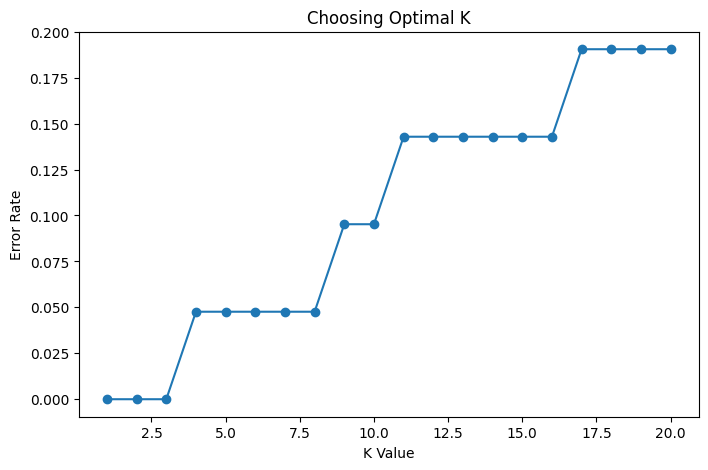

In [19]:
error_rate = []

from sklearn.neighbors import KNeighborsClassifier

for i in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred = knn.predict(X_test)
    error_rate.append(np.mean(pred != y_test))

plt.figure(figsize=(8,5))
plt.plot(range(1,21),error_rate,marker='o')
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("Choosing Optimal K")
plt.show()

Interpretation

The graph helps choose the best K value.

Select the K with the lowest error rate (commonly K = 3 or 5).

Build KNN Model

In [20]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

knn.fit(X_train,y_train)

KNeighborsClassifier(metric='euclidean')

Interpretation

Built the KNN classifier using K = 5.
Euclidean distance is used.

Prediction

In [21]:
y_pred = knn.predict(X_test)

Interpretation
The trained model predicts the animal types on the test data.

Model Evaluation

In [22]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print("Accuracy :",accuracy_score(y_test,y_pred))

print("Precision :",precision_score(y_test,y_pred,average='weighted'))

print("Recall :",recall_score(y_test,y_pred,average='weighted'))

print("F1 Score :",f1_score(y_test,y_pred,average='weighted'))

Accuracy : 0.9523809523809523
Precision : 0.9206349206349207
Recall : 0.9523809523809523
F1 Score : 0.9333333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Interpretation

Accuracy measures overall correctness.
Precision measures the quality of positive predictions.
Recall measures the ability to identify actual classes.
F1-score balances precision and recall.

Classification Report

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Interpretation

Displays Precision, Recall, F1-score, and Support for each animal type.

Confusion Matrix

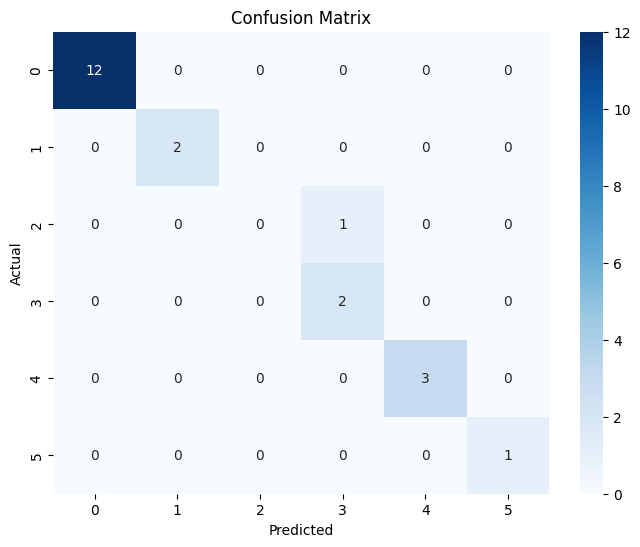

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Interpretation

Shows correctly and incorrectly classified animals.

Decision Boundary Visualization

Since the Zoo dataset has 16 input features, it is not possible to directly visualize decision boundaries in 2D. Reduce the data to two dimensions using PCA.

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_train_pca,X_test_pca,y_train_pca,y_test_pca=train_test_split(
    X_pca,y,test_size=0.2,random_state=42
)

knn_pca = KNeighborsClassifier(n_neighbors=5)

knn_pca.fit(X_train_pca,y_train_pca)

KNeighborsClassifier()

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


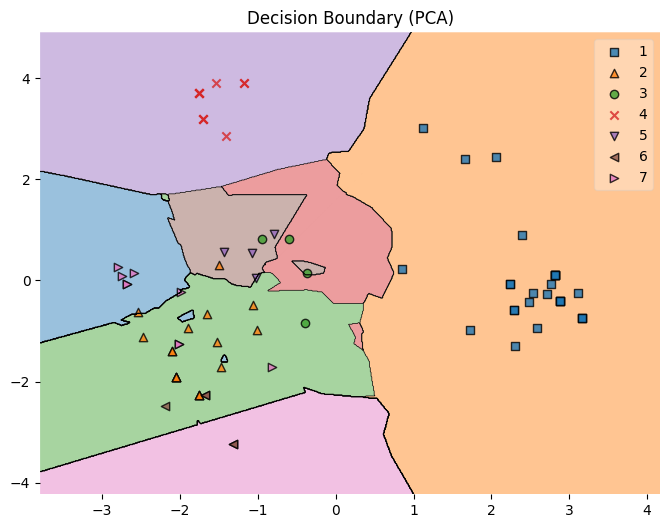

In [26]:
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(8,6))

plot_decision_regions(X_train_pca,y_train_pca.to_numpy(),clf=knn_pca)

plt.title("Decision Boundary (PCA)")
plt.show()

Interpretation

PCA reduces the features to two dimensions.
The plot shows how KNN separates the classes.
The boundaries illustrate the classification regio

Final Conclusion

The Zoo dataset was analyzed using Exploratory Data Analysis (EDA), and no missing values or significant outliers were found. The animal name column was removed because it is only an identifier. Features were standardized before training the KNN model. The data was split into 80% training and 20% testing. A KNN classifier with Euclidean distance and an appropriate K value was trained and evaluated using Accuracy, Precision, Recall, and F1-score. PCA was applied to visualize the decision boundaries. The KNN model successfully classified different animal types and demonstrated good classification performance.

*Interview Questions*

1. What are the key hyperparameters in KNN?

Answer:

n_neighbors (K): Number of nearest neighbors used for prediction.

metric: Distance metric (Euclidean, Manhattan, Minkowski, etc.).

weights: Uniform or distance-based weighting of neighbors.

algorithm: Method used to compute nearest neighbors (auto, ball_tree, kd_tree, brute).

leaf_size: Controls the speed of Ball Tree and KD Tree algorithms.

2. What distance metrics can be used in KNN?

Answer:

Euclidean Distance: Most commonly used for continuous numerical data.

Manhattan Distance: Sum of absolute differences; useful for grid-like data.

Minkowski Distance: Generalization of Euclidean and Manhattan distances.

Chebyshev Distance: Maximum absolute difference between coordinates.

Hamming Distance: Suitable for binary or categorical features.

Cosine Distance: Used to compare the orientation of vectors rather than magnitude.